# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset



## Setup

In [44]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')


csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [45]:
print("Số dòng: ", df.shape[0], "| Số cột: ", df.shape[1])
print("Tên các cột: ", df.columns.tolist())
print()
df.info()

Số dòng:  1338 | Số cột:  7
Tên các cột:  ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


## A.2. Missing values & Duplicate data

In [46]:
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "Không có cột thiếu dữ liệu.")
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values:
Không có cột thiếu dữ liệu.

Duplicate rows: 1


## A.3. Invalid values

In [47]:
print("Giới tính: ", df['sex'].unique().tolist())
print("Chi phí<0: ", (df['charges']<0).sum())
print("Khu vực: ", df['region'].unique())
print("Tuổi<0: ", (df['age']<0).sum())

Giới tính:  ['female', 'male']
Chi phí<0:  0
Khu vực:  <StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str
Tuổi<0:  0


## A.4. Create a new column
Tạo cột `bmi_group`: Normal (<25), Overweight (25-30), Obese (>=30).

In [48]:
def loai_bmi(bmi):
    if bmi<25:
        return "Normal"
    elif bmi>=30:
        return "Obese"
    else:
        return "Overweight"
df['bmi_group'] = df['bmi'].apply(loai_bmi)
df


,age,sex,bmi,children,smoker,region,charges,bmi_group
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,Obese
1334,18,female,31.920,0,no,northeast,2205.98080,Obese
1335,18,female,36.850,0,no,southeast,1629.83350,Obese
1336,21,female,25.800,0,no,southwest,2007.94500,Overweight


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [49]:
for col in ['age', 'bmi', 'children', 'charges']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: Mean={mean_}, Median={median_}, Mode={mode_}")

age: Mean=39.20702541106129, Median=39.0, Mode=18
bmi: Mean=30.66339686098655, Median=30.4, Mode=32.3
children: Mean=1.0949177877429, Median=1.0, Mode=0
charges: Mean=13270.422265141257, Median=9382.033, Mode=1639.5631


## Group 2 — Dispersion

In [50]:
for col in ['age', 'bmi', 'children', 'charges']:
    s = df[col]
    range_ = s.max() - s.min()
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    std_ = s.std()
    cv = s.std() / s.mean() * 100
    print(f"---{col}---")
    print(f"range= {range_}, iqr= {iqr}, std= {std_}, cv= {cv}")


---age---
range= 46, iqr= 24.0, std= 14.049960379216154, cv= 35.8353132682499
---bmi---
range= 37.17, iqr= 8.3975, std= 6.098186911679014, cv= 19.88751259139792
---children---
range= 5, iqr= 2.0, std= 1.205492739781914, cv= 110.09892736028675
---charges---
range= 62648.554110000005, iqr= 11899.625365, std= 12110.011236694001, cv= 91.25565859727446


## Group 3 — Location and Shape

---age---
skew= 0.05561008307259911, kurtosis= -1.2449206804584227
---bmi---
skew= 0.28372857291709386, kurtosis= -0.05502310583700032
---children---
skew= 0.9373281163874424, kurtosis= 0.1972174268623732
---charges---
skew= 1.5141797118745743, kurtosis= 1.595821363956751


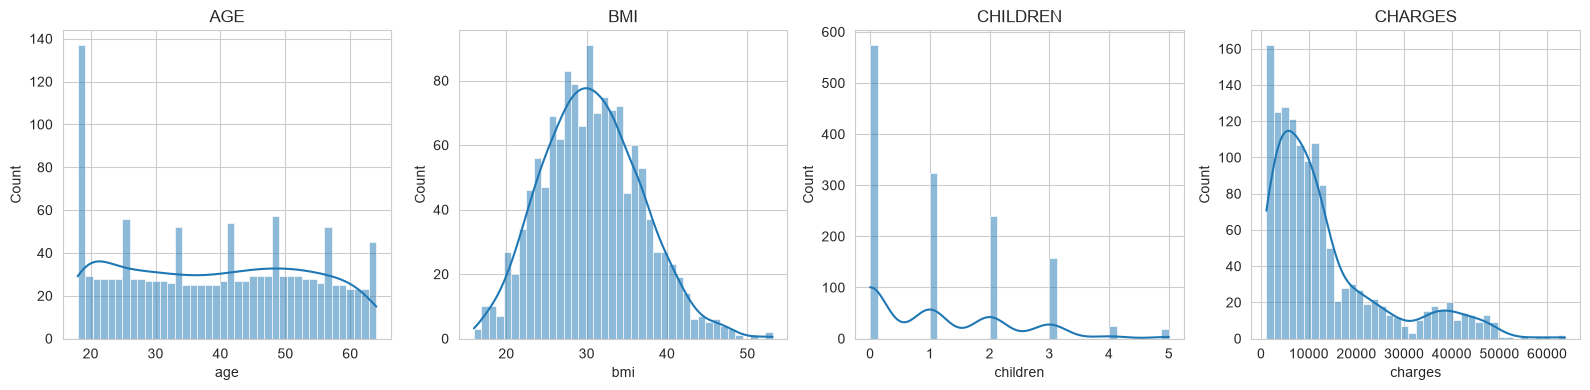

In [51]:
for col in ['age', 'bmi', 'children', 'charges']:
    s = df[col]
    skew_, kurtosis_ = stats.skew(s), stats.kurtosis(s)
    print(f"---{col}---")
    print(f"skew= {skew_}, kurtosis= {kurtosis_}")
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
sns.histplot(df['age'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('AGE')
sns.histplot(df['bmi'], bins=40, kde=True, ax=axes[1])
axes[1].set_title('BMI')
sns.histplot(df['children'], bins=40, kde=True, ax=axes[2])
axes[2].set_title('CHILDREN')
sns.histplot(df['charges'], bins=40, kde=True, ax=axes[3])
axes[3].set_title('CHARGES')
plt.tight_layout()
plt.show()


In [52]:
print("Nhận xét: Age có skewness khá gần 0 nên phân phối tương đối cân đối, kurtosis âm cho thấy phân phối hơi bẹt.")
print("BMI có độ lệch phải nhẹ, trong khi kurtosis gần 0 cho thấy hình dạng phân phối không khác quá nhiều so với phân phối chuẩn.")
print("Children có xu hướng lệch phải do phần lớn dữ liệu tập trung ở số con thấp, đặc biệt là 0, 1 và 2.")
print("Charges bị lệch phải khá rõ, cho thấy một số khách hàng có mức chi phí bảo hiểm cao bất thường.")

Nhận xét: Age có skewness khá gần 0 nên phân phối tương đối cân đối, kurtosis âm cho thấy phân phối hơi bẹt.
BMI có độ lệch phải nhẹ, trong khi kurtosis gần 0 cho thấy hình dạng phân phối không khác quá nhiều so với phân phối chuẩn.
Children có xu hướng lệch phải do phần lớn dữ liệu tập trung ở số con thấp, đặc biệt là 0, 1 và 2.
Charges bị lệch phải khá rõ, cho thấy một số khách hàng có mức chi phí bảo hiểm cao bất thường.


---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

In [53]:
chi_phi_tb = df.groupby(['region', 'smoker'])['charges'].mean().unstack()
ty_le = chi_phi_tb['yes'] / chi_phi_tb['no']
print(chi_phi_tb)
print()
print("Người hút thuốc trả chi phí chênh lệch với người không hút thuốc tương đối đồng đều giữa các vùng")
print(ty_le)
print(ty_le.mean())

smoker              no           yes
region                              
northeast  9165.531672  29673.536473
northwest  8556.463715  30192.003182
southeast  8032.216309  34844.996824
southwest  8019.284513  32269.063494

Người hút thuốc trả chi phí chênh lệch với người không hút thuốc tương đối đồng đều giữa các vùng
region
northeast    3.237514
northwest    3.528561
southeast    4.338155
southwest    4.023933
dtype: float64
3.78204062277295


## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

In [54]:
co_hut = df[df['smoker'] == 'yes']['bmi'].corr(
    df[df['smoker'] == 'yes']['charges']
)
khong_hut = df[df['smoker'] == 'no']['bmi'].corr(
    df[df['smoker'] == 'no']['charges']
)
print("Có hút thuốc: ", co_hut.round(2))
print("Không hút thuốc: ", khong_hut.round(2))
print("Nhận xét: BMI có mối tương quan với chi phí bảo hiểm mạnh hơn ở nhóm có hút thuốc.")

Có hút thuốc:  0.81
Không hút thuốc:  0.08
Nhận xét: BMI có mối tương quan với chi phí bảo hiểm mạnh hơn ở nhóm có hút thuốc.


## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

In [55]:
chi_phi_tb = df.groupby('region')['charges'].mean()
print("Vùng có chi phí bảo hiểm trung bình cao nhất:", chi_phi_tb.idxmax())
print("Chi phí trung bình =", chi_phi_tb.max())

Vùng có chi phí bảo hiểm trung bình cao nhất: southeast
Chi phí trung bình = 14735.41143760989


## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?

In [56]:
chi_phi_con = df.groupby('children')['charges'].mean().sort_index()
print(chi_phi_con)
print("Nhận xét: Chi phí bảo hiểm chưa có xu hướng tăng hoặc giảm ổn định theo số lượng con. ""Từ 0 đến 3 con, chi phí trung bình có xu hướng tăng, nhưng từ 3 đến 5 con lại có xu hướng giảm.")


children
0    12365.975602
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64
Nhận xét: Chi phí bảo hiểm chưa có xu hướng tăng hoặc giảm ổn định theo số lượng con. Từ 0 đến 3 con, chi phí trung bình có xu hướng tăng, nhưng từ 3 đến 5 con lại có xu hướng giảm.


## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

In [57]:
tuoi_chi_phi = df['age'].corr(df['charges'])
print("Tương quan tuổi - chi phí:", tuoi_chi_phi.round(2))
print("Nhận xét: Tuổi và chi phí bảo hiểm có tương quan dương nhưng khá yếu, tức là khi tuổi tăng thì chi phí có xu hướng tăng nhưng không quá rõ rệt.")


Tương quan tuổi - chi phí: 0.3
Nhận xét: Tuổi và chi phí bảo hiểm có tương quan dương nhưng khá yếu, tức là khi tuổi tăng thì chi phí có xu hướng tăng nhưng không quá rõ rệt.


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

Dữ liệu có 1.338 dòng, không có giá trị thiếu và không phát hiện giá trị không hợp lệ ở các trường được kiểm tra. Tuy nhiên, dữ liệu vẫn có 1 dòng bị trùng.

Chi phí bảo hiểm (charges) có độ phân tán lớn và phân phối lệch phải, cho thấy một số khách hàng có mức chi phí cao hơn rất nhiều so với phần lớn khách hàng.

Tình trạng hút thuốc có sự khác biệt rõ rệt về chi phí bảo hiểm. Người hút thuốc có chi phí trung bình cao hơn nhiều lần so với người không hút thuốc, và sự chênh lệch này tương đối đồng đều giữa các vùng.

Tuổi và BMI đều có mối tương quan với chi phí bảo hiểm, nhưng mức độ tương quan không quá mạnh. BMI có mối tương quan khác nhau giữa nhóm hút thuốc và không hút thuốc.

Số lượng con không cho thấy xu hướng làm chi phí bảo hiểm tăng ổn định. Xét theo khu vực, Southeast là vùng có chi phí bảo hiểm trung bình cao nhất.